# Analyzing Box Chart Using Open CV

In [2]:
#pip install openpyxl
#pip install opencv-python

In [2]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

/srv/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "orientation" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/srv/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "facecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/srv/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "edgecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/srv/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword ar

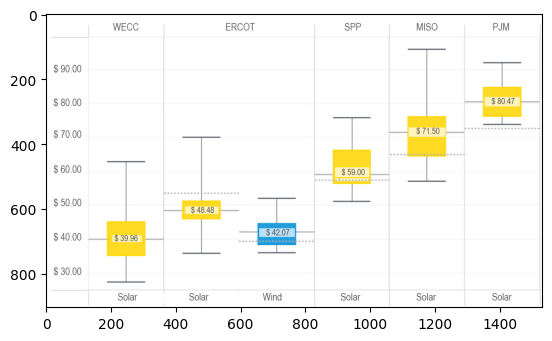

In [3]:
# Upload your picture and set format as png
image_path = 'put_your_picture.png'
image = cv2.imread(image_path)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis('on')
plt.show()

# Convert the image to HSV color space
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)


To get your desired color, please open this link path ("G:\Shared drives\USS\PPA\Automated_data_extraction\Code\r2 (the second revision)\Color Setting") to detect your color and get the HSV code

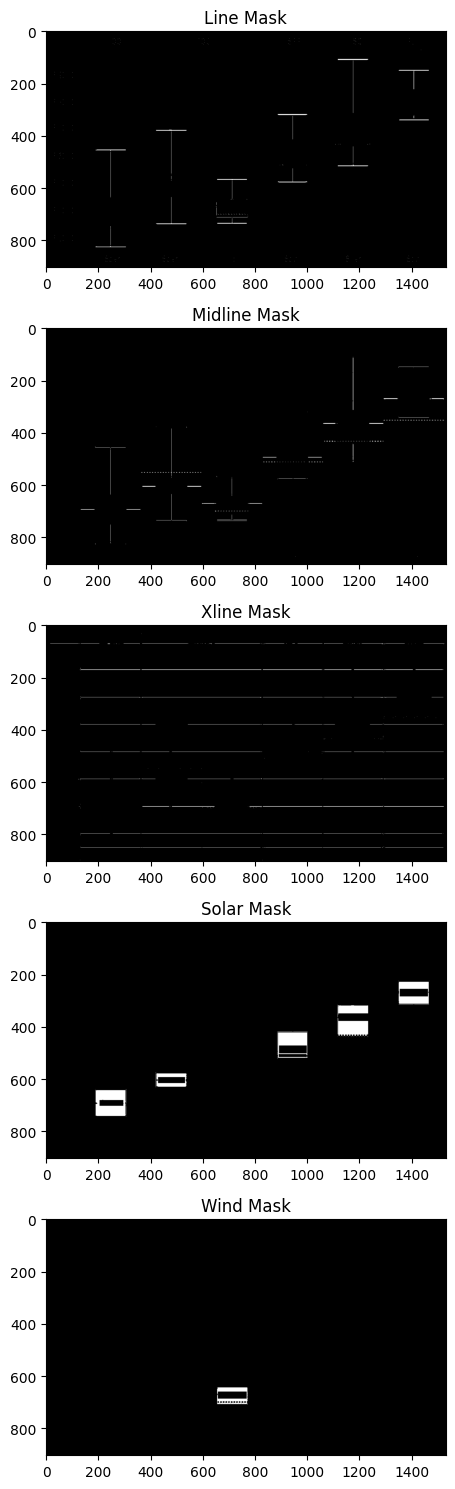

In [4]:
# Define HSV ranges for different colors (Line, Midline, XLine, Solar, Wind)
color_ranges = {
    'Line': ((101, 18, 98), (121, 50, 255)), #set your HSV code here
    'Midline': ((97, 0, 170), (117, 17, 190)),
    'XLine': ((0, 0, 243), (0, 0, 245)),
    'Solar': ((15, 209, 245), (35, 229, 255)),
    'Wind': ((90, 203, 209), (110, 223, 229))
}

# Create masks for each color
masks = {color: cv2.inRange(hsv, np.array(range[0]), np.array(range[1])) for color, range in color_ranges.items()}

# Visualize masks
fig, axes = plt.subplots(len(masks), 1, figsize=(5, 15))
for i, (color, mask) in enumerate(masks.items()):
    axes[i].imshow(mask, cmap='gray')
    axes[i].set_title(f'{color.capitalize()} Mask')
    axes[i].axis('on')

plt.tight_layout()
plt.show()

In [5]:
# Function to extract data points (multiple y values)
def extract_data(mask):
    data_points = {}
    for i in range(mask.shape[1]):
        column = mask[:, i]
        y_points = np.where(column)[0]
        if len(y_points) > 0:
            data_points[i] = list(image.shape[0] - y_points)  # Adjust y-coordinates
    return data_points

# Extract data points for each color
data = {color: extract_data(mask) for color, mask in masks.items()}

In [6]:
# Combine data into a single DataFrame with lists in each column
combined_df = pd.DataFrame({
    'X (pixels)': list(data['Line'].keys()),
    'Y (Line)': [data['Line'][x] if x in data['Line'] else [] for x in data['Line'].keys()],
    'Y (XLine)': [data['XLine'][x] if x in data['XLine'] else [] for x in data['Line'].keys()],
    'Y (Midline)': [data['Midline'][x][0] if x in data['Midline'] else np.nan for x in data['Line'].keys()],
    'Y Solar (25)': [max(data['Solar'][x]) if x in data['Solar'] and data['Solar'][x] else np.nan for x in data['Line'].keys()],
    'Y Solar (75)': [min(data['Solar'][x]) if x in data['Solar'] and data['Solar'][x] else np.nan for x in data['Line'].keys()],
    'Y Wind (25)': [max(data['Wind'][x]) if x in data['Wind'] and data['Wind'][x] else np.nan for x in data['Line'].keys()],
    'Y Wind (75)': [min(data['Wind'][x]) if x in data['Wind'] and data['Wind'][x] else np.nan for x in data['Line'].keys()],
})

display(combined_df.head())

,X (pixels),Y (Line),Y (XLine),Y (Midline),Y Solar (25),Y Solar (75),Y Wind (25),Y Wind (75)
0,32,"[737, 633, 535, 427, 324, 218, 112]",[834],NaN,NaN,NaN,NaN,NaN
1,33,"[747, 643, 545, 437, 334, 228, 122]",[834],NaN,NaN,NaN,NaN,NaN
2,51,"[435, 417]",[834],NaN,NaN,NaN,NaN,NaN
3,54,"[747, 733, 725, 100]",[834],NaN,NaN,NaN,NaN,NaN
4,55,"[437, 429]",[834],NaN,NaN,NaN,NaN,NaN


# Scaling X-Y Axis

In this section, We will scale 25-75% percentile to know the data. We have filtered the boxes, our next task is to know the value of each box. There are several steps:

1. Import the data to Excel (combined_df.to_excel(excel_path_raw, index=False) to get the raw data. Please run the line code below this instruction.
2. Check the X-line mask in the Excel. X-axis or 'X (pixels)' column is very pivotal, where it has many numbers as a matrix. Each data represents the value that can be used as a reference
    - Example: [100,200,300] may represent [20,30,40] in real Y value
4. Put the real Y value and Xline value in 'converter_table' below

In [ ]:
# Save raw data to Excel
excel_path_raw = 'PPA_trio_raw.xlsx'
combined_df.to_excel(excel_path_raw, index=False)

In [7]:
# Converter table (example provided)
converter_table = {
    90: 735.5, #Left side represents real Y value, right side is our raw data
    80: 628,
    70: 524,
    60: 419,
    50: 315,
    40: 209.5,
    30: 106
}

# Convert the table into a sorted list of tuples for interpolation
converter_points = sorted(converter_table.items(), reverse=True)

# Function to interpolate a single Y value to the real-world value
def interpolate_y_value(pixel_value):
    for i in range(len(converter_points) - 1):
        y1, real_y1 = converter_points[i]
        y2, real_y2 = converter_points[i + 1]

        if real_y1 >= pixel_value >= real_y2:
            # Perform linear interpolation
            slope = (y2 - y1) / (real_y2 - real_y1)
            intercept = y1 - slope * real_y1
            return slope * pixel_value + intercept
    
    # Return np.nan if the value is out of bounds
    return np.nan

# Apply the interpolation to the dataframe columns
for col in ['Y Solar (25)', 'Y Solar (75)', 'Y Wind (25)', 'Y Wind (75)']:
    combined_df[f'Real {col}'] = combined_df[col].apply(interpolate_y_value)

combined_df

,X (pixels),Y (Line),Y (XLine),Y (Midline),Y Solar (25),Y Solar (75),Y Wind (25),Y Wind (75),Real Y Solar (25),Real Y Solar (75),Real Y Wind (25),Real Y Wind (75)
0,32,"[737, 633, 535, 427, 324, 218, 112]",[834],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,33,"[747, 643, 545, 437, 334, 228, 122]",[834],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,51,"[435, 417]",[834],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,54,"[747, 733, 725, 100]",[834],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,55,"[437, 429]",[834],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
712,1461,"[755, 754, 753, 565, 564, 563]","[834, 734, 733, 554, 524, 419, 315, 210, 209, ...",756.0,675.0,588.0,NaN,NaN,84.372093,76.153846,NaN,NaN
713,1462,"[755, 754, 753, 565, 564, 563]","[834, 734, 733, 524, 419, 315, 210, 209, 106, 52]",756.0,675.0,588.0,NaN,NaN,84.372093,76.153846,NaN,NaN
714,1463,"[755, 754, 753, 565, 564, 563]","[834, 734, 733, 524, 419, 315, 210, 209, 106, 52]",756.0,675.0,588.0,NaN,NaN,84.372093,76.153846,NaN,NaN
715,1464,"[755, 754, 753, 565, 564, 563]","[834, 734, 733, 524, 419, 315, 210, 209, 106, 52]",756.0,675.0,588.0,NaN,NaN,84.372093,76.153846,NaN,NaN


In [8]:
# Save raw data to Excel
excel_path_raw = 'PPA_trio.xlsx'
combined_df.to_excel(excel_path_raw, index=False)